In [26]:
                                                  # Heart Disease Dataset EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\rajan\Downloads\heart_disease_uci (1).csv")
if "id" in df.columns:
    df = df.drop(columns=["id"])

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())



Dataset Shape:
(920, 15)

First 5 Rows:
   age     sex    dataset               cp  trestbps   chol    fbs  \
0   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal

In [27]:
# 3. Create binary target
# Original column: num
# 0 = no heart disease
# 1,2,3,4 = heart disease present

df["heart_disease"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

print("\nTarget Distribution:")
print(df["heart_disease"].value_counts())

print("\nTarget Distribution Percentage:")
print(df["heart_disease"].value_counts(normalize=True) * 100)


Target Distribution:
heart_disease
1    509
0    411
Name: count, dtype: int64

Target Distribution Percentage:
heart_disease
1    55.326087
0    44.673913
Name: proportion, dtype: float64


In [28]:
# 4. Separate column types

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)


# 5. Summary statistics

print("\nSummary Statistics:")
print(df.describe())

print("\nCategorical Summary:")
print(df.describe(include=["object", "bool"]))


Numerical Columns:
Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num',
       'heart_disease'],
      dtype='object')

Categorical Columns:
Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')

Summary Statistics:
              age    trestbps        chol      thalch     oldpeak          ca  \
count  920.000000  861.000000  890.000000  865.000000  858.000000  309.000000   
mean    53.510870  132.132404  199.130337  137.545665    0.878788    0.676375   
std      9.424685   19.066070  110.780810   25.926276    1.091226    0.935653   
min     28.000000    0.000000    0.000000   60.000000   -2.600000    0.000000   
25%     47.000000  120.000000  175.000000  120.000000    0.000000    0.000000   
50%     54.000000  130.000000  223.000000  140.000000    0.500000    0.000000   
75%     60.000000  140.000000  268.000000  157.000000    1.500000    1.000000   
max     77.000000  200.000000  603.000000  202.000000    6.200000    3.000000   



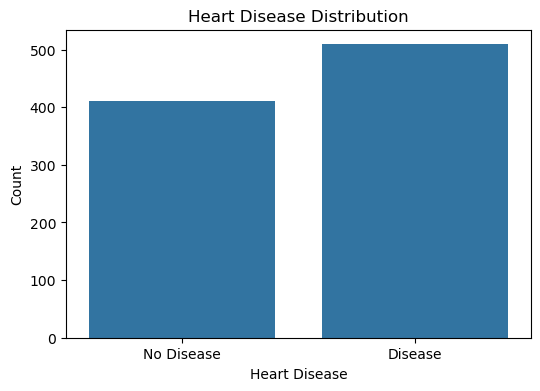

In [29]:
# 6. Target variable plot

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="heart_disease")
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Disease", "Disease"])
plt.show()


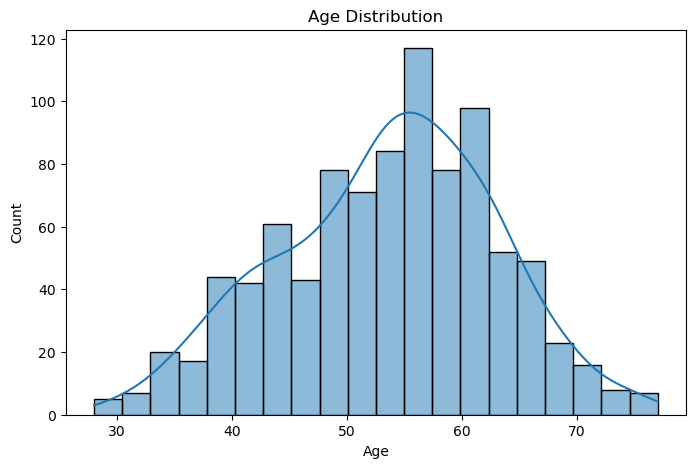

In [30]:
# 7. Age distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


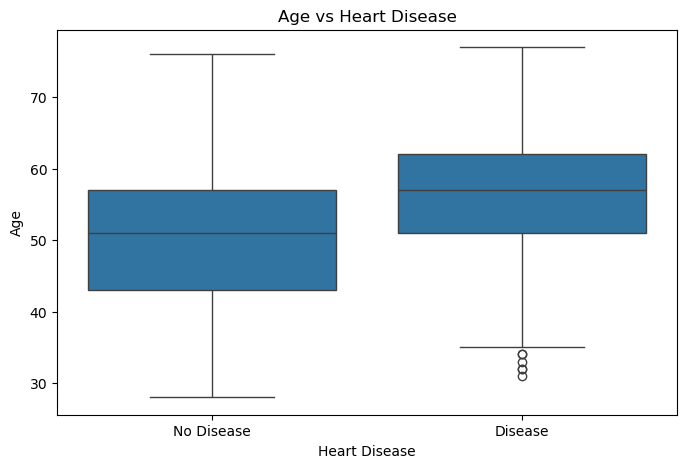

In [31]:
# 8. Age vs heart disease

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="heart_disease", y="age")
plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.xticks([0, 1], ["No Disease", "Disease"])
plt.show()

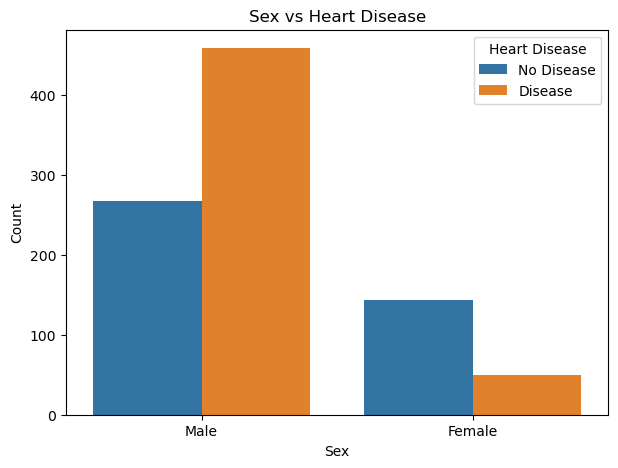

In [32]:
# 9. Sex vs heart disease

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="sex", hue="heart_disease")
plt.title("Sex vs Heart Disease")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])
plt.show()



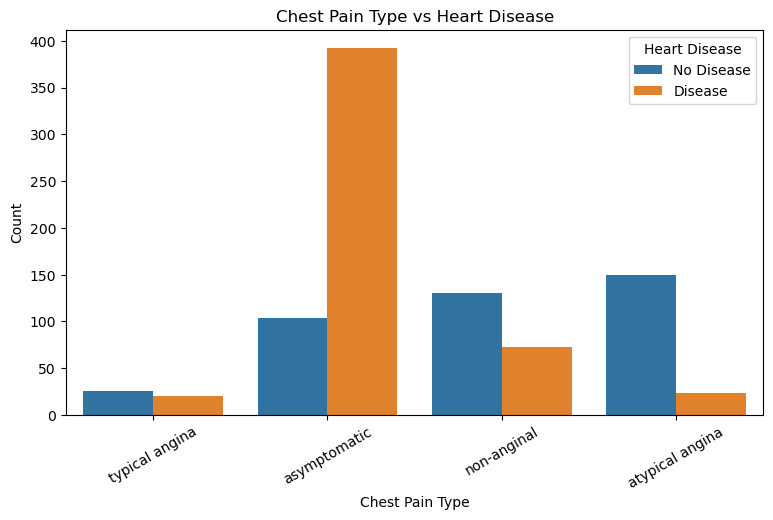

In [33]:

# 10. Chest pain type vs heart disease

plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="cp", hue="heart_disease")
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])
plt.show()


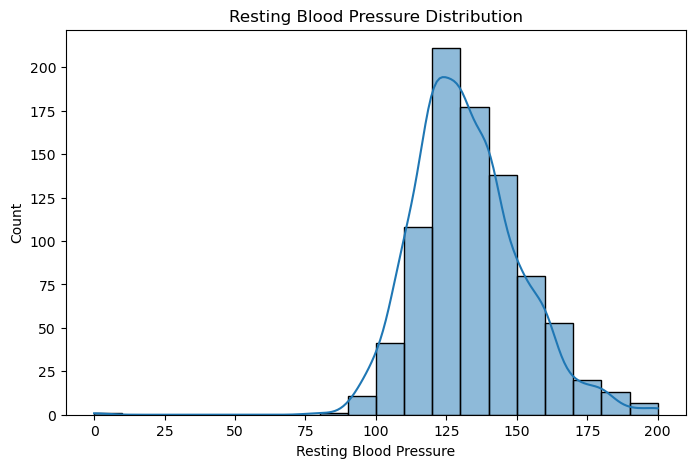

In [34]:
# 11. Resting blood pressure distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="trestbps", bins=20, kde=True)
plt.title("Resting Blood Pressure Distribution")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Count")
plt.show()

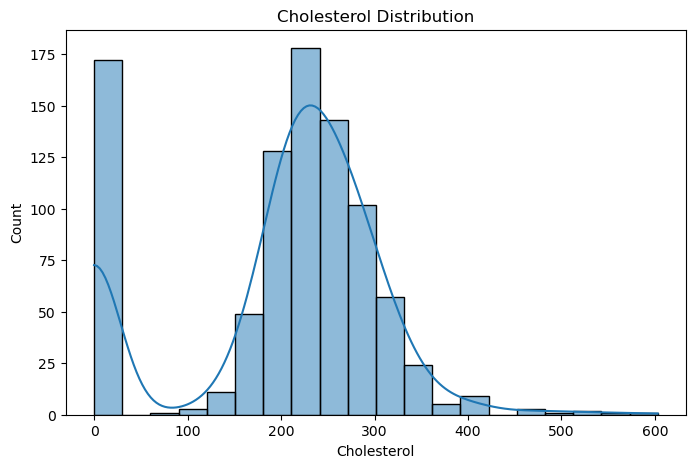

In [35]:
# 12. Cholesterol distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="chol", bins=20, kde=True)
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Count")
plt.show()

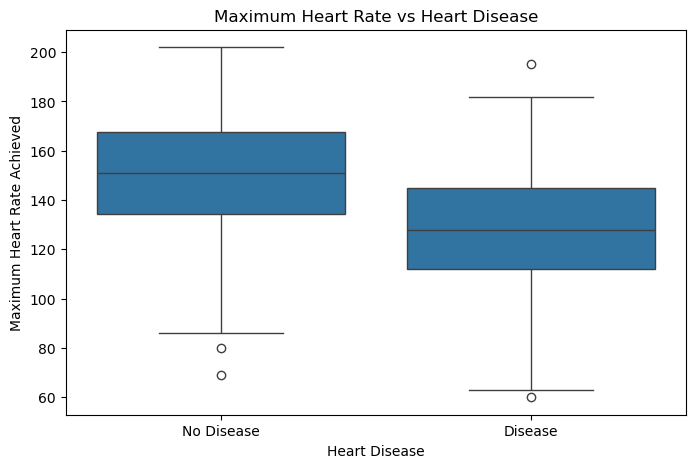

In [36]:
# 13. Maximum heart rate vs heart disease

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="heart_disease", y="thalch")
plt.title("Maximum Heart Rate vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate Achieved")
plt.xticks([0, 1], ["No Disease", "Disease"])
plt.show()

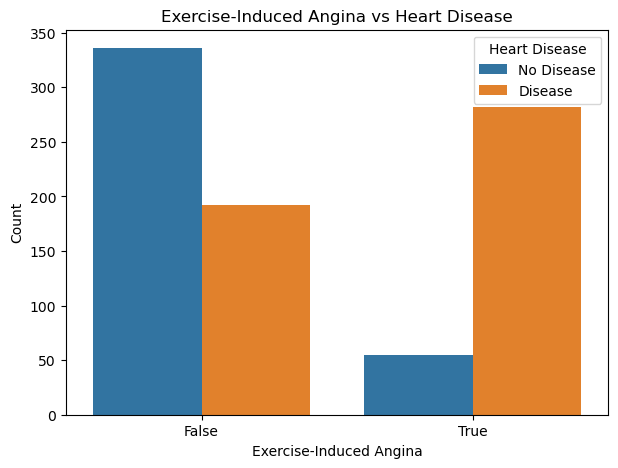

In [37]:
# 14. Exercise-induced angina vs heart disease

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="exang", hue="heart_disease")
plt.title("Exercise-Induced Angina vs Heart Disease")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Count")
plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])
plt.show()

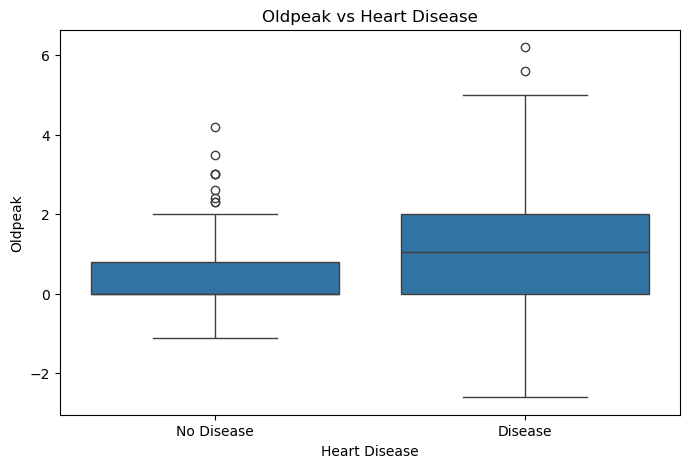

In [38]:
# 15. Oldpeak vs heart disease

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="heart_disease", y="oldpeak")
plt.title("Oldpeak vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Oldpeak")
plt.xticks([0, 1], ["No Disease", "Disease"])
plt.show()

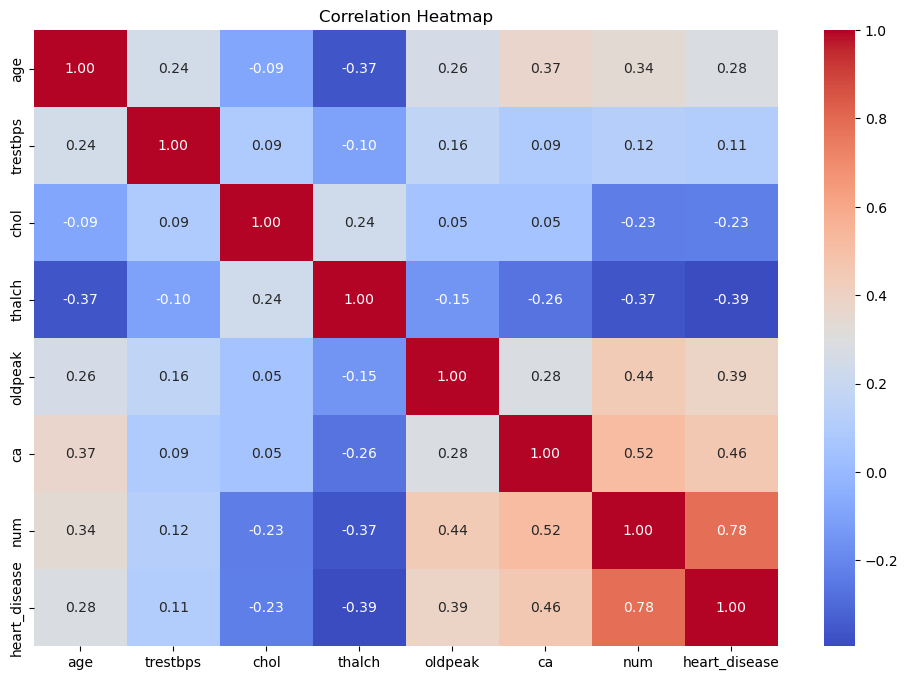

In [39]:
# 16. Correlation heatmap
# Only numeric columns are used

plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

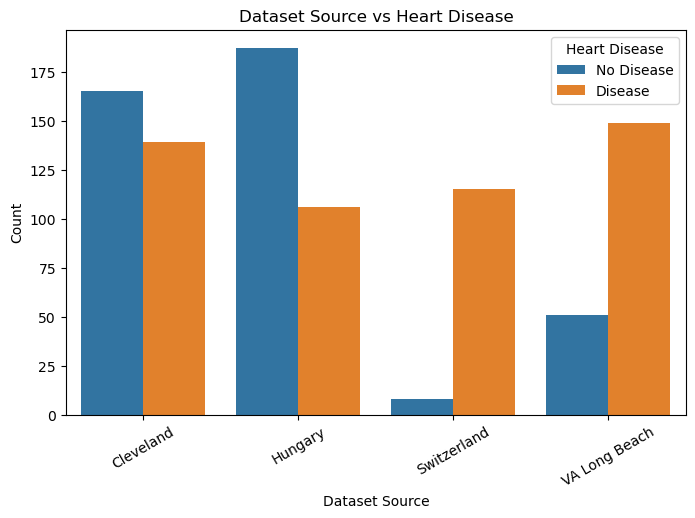

In [40]:
# 17. Dataset source comparison

if "dataset" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x="dataset", hue="heart_disease")
    plt.title("Dataset Source vs Heart Disease")
    plt.xlabel("Dataset Source")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])
    plt.show()

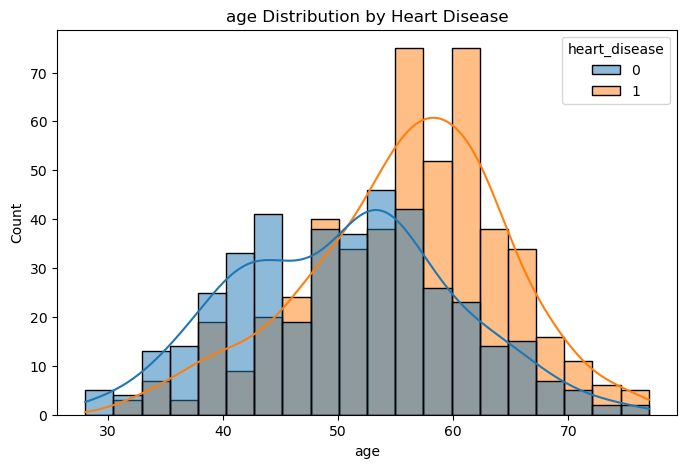

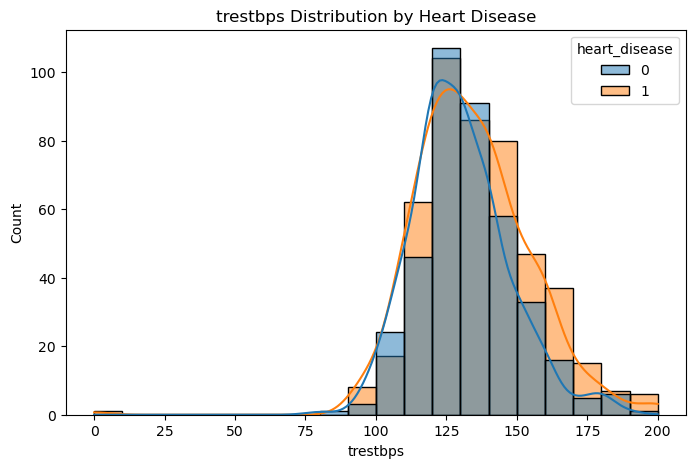

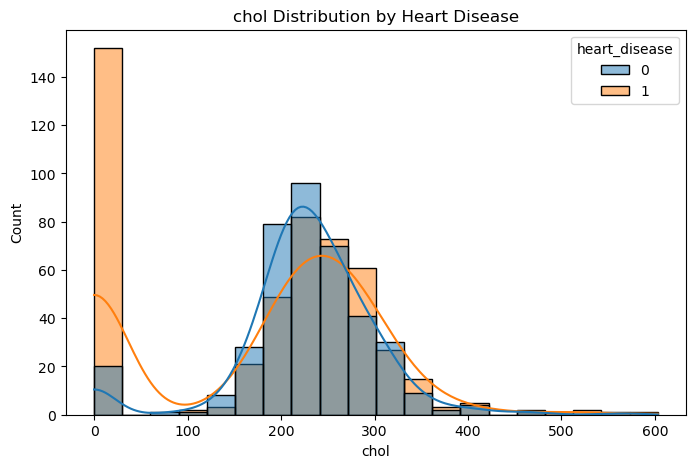

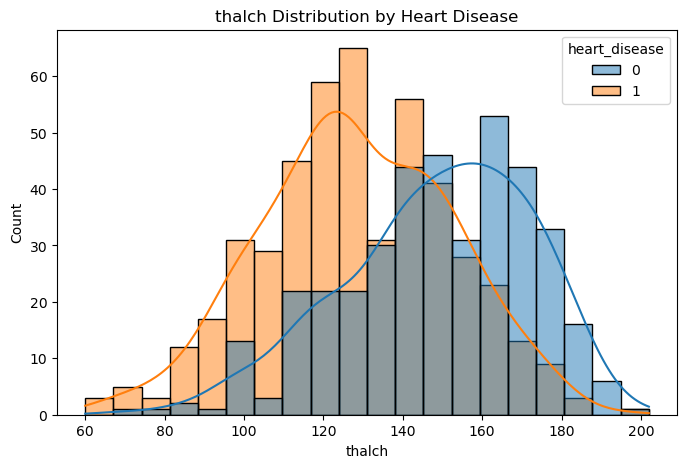

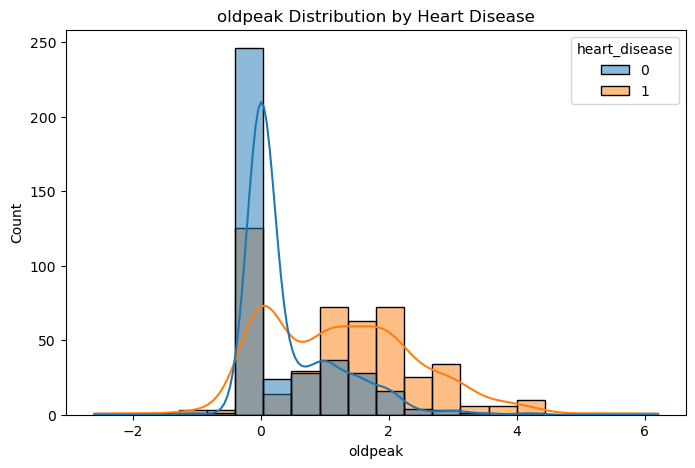

In [41]:
# 18. Numeric feature distributions by target

selected_numeric = ["age", "trestbps", "chol", "thalch", "oldpeak"]

for col in selected_numeric:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(data=df, x=col, hue="heart_disease", kde=True, bins=20)
        plt.title(f"{col} Distribution by Heart Disease")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()


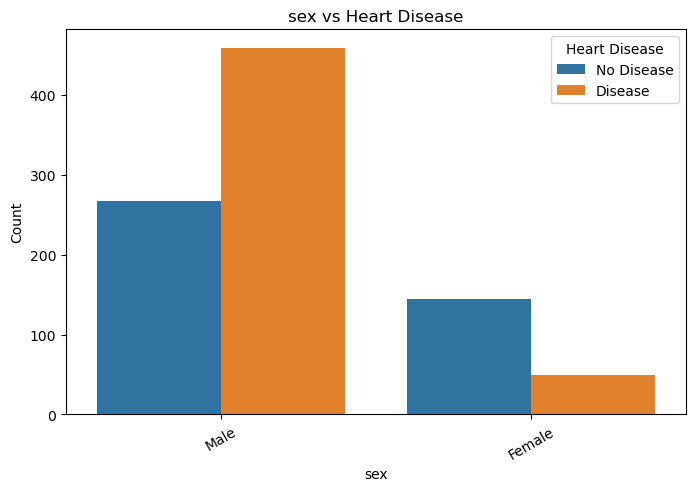

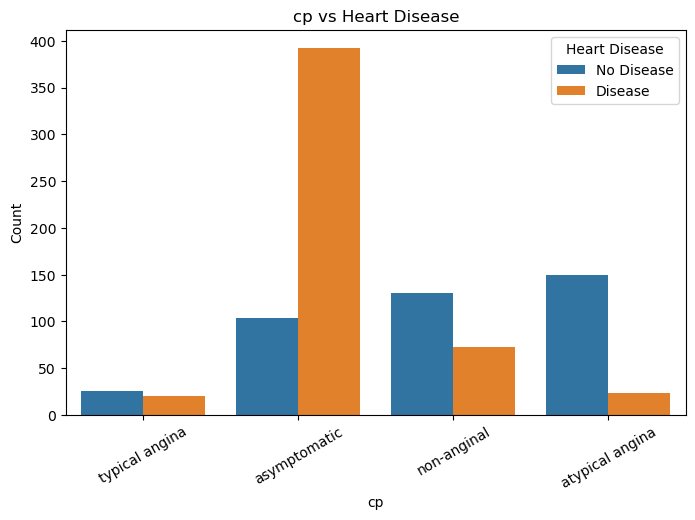

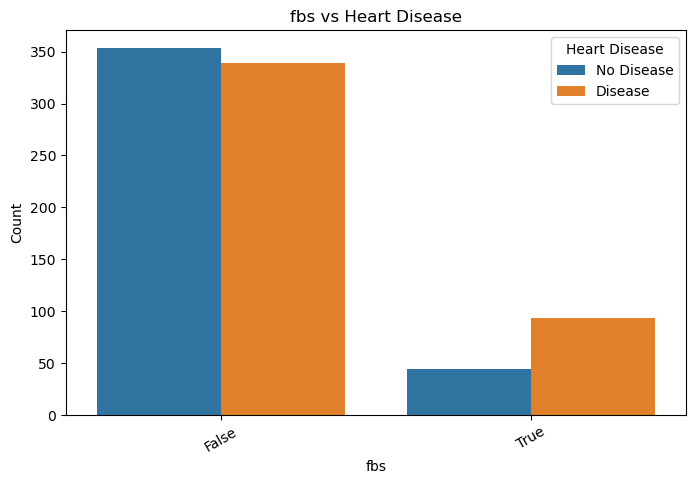

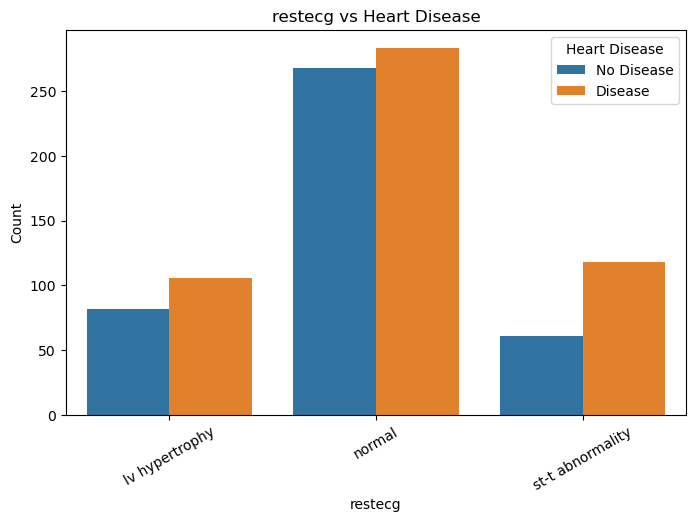

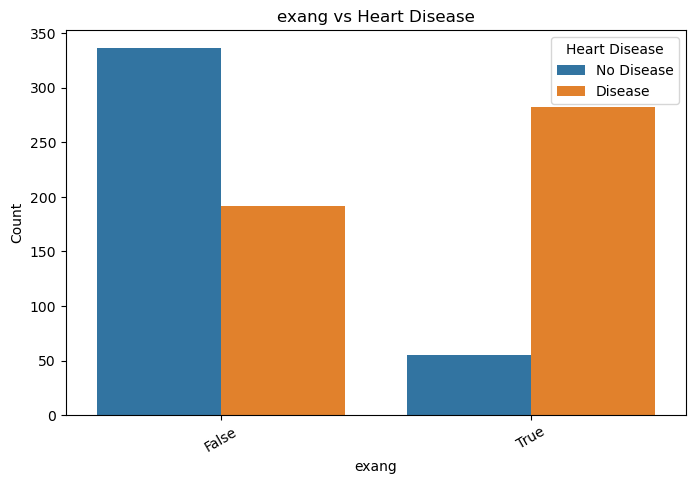

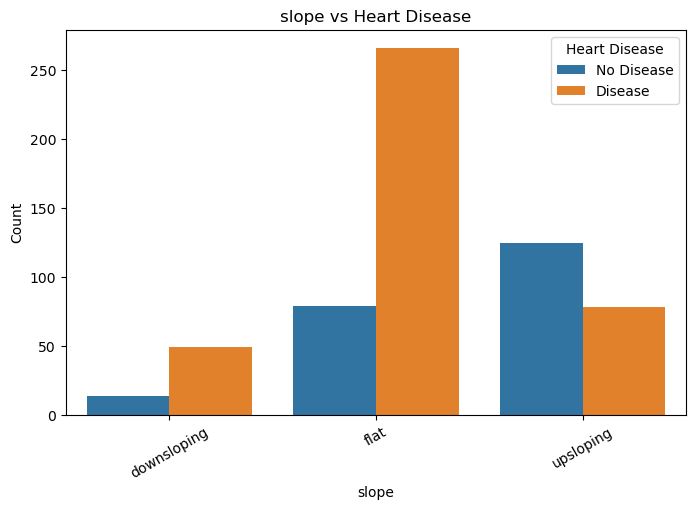

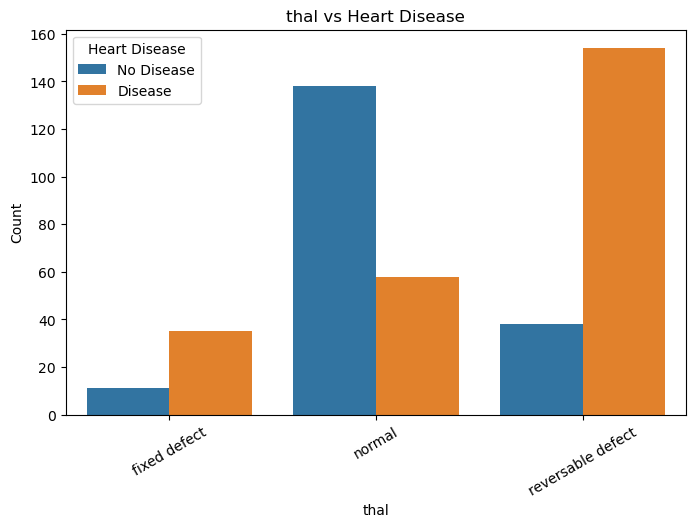

In [42]:
# 19. Categorical feature counts by target

selected_categorical = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

for col in selected_categorical:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=df, x=col, hue="heart_disease")
        plt.title(f"{col} vs Heart Disease")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=30)
        plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])
        plt.show()

In [43]:
                                          # KNN Model: Heart Disease Prediction
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv(r"C:\Users\rajan\Downloads\heart_disease_uci (1).csv")

df = df.dropna()

print("Dataset shape after dropping NaN values:", df.shape)


Dataset shape after dropping NaN values: (299, 16)


In [44]:
# 1. Create binary target variable
# In this dataset:
# num = 0 means no heart disease
# num = 1, 2, 3, or 4 means heart disease is present

df["heart_disease"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

# 2. Split features and target

X = df.drop(columns=["num", "heart_disease"])
y = df["heart_disease"]

# Drop id column if it exists because it is only an identifier
if "id" in X.columns:
    X = X.drop(columns=["id"])

In [45]:
# 3. Identify numerical and categorical columns

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns

print("Numerical columns:")
print(list(numerical_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Numerical columns:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

Categorical columns:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [46]:
# 4. Preprocessing
# KNN needs numbers only.
# Numerical columns are scaled.
# Categorical columns are one-hot encoded.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [47]:
# 5. KNN pipeline

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("knn", KNeighborsClassifier())
    ]
)

In [48]:
# 6. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [51]:
# 7. Tuning KNN hyperparameters
param_grid = {
    "knn__n_neighbors": list(range(1, 31)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest KNN Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(grid_search.best_score_, 4))


Best KNN Parameters:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 28, 'knn__weights': 'distance'}

Best Cross-Validation Accuracy:
0.845


In [52]:
# 8. Make Prediction 
best_knn_model = grid_search.best_estimator_

y_pred = best_knn_model.predict(X_test)
y_pred_proba = best_knn_model.predict_proba(X_test)[:, 1]


In [54]:
# 9. Evaluating the Model 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\nKNN Model Performance:")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


KNN Model Performance:
Accuracy: 0.8333
Precision: 0.875
Recall: 0.75
F1 Score: 0.8077
ROC-AUC: 0.9319

Confusion Matrix:
[[29  3]
 [ 7 21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.85        32
           1       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60

